# 02. AR and MA processes, ACF and PACF

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ahleksu/arima-workshop-ccis/blob/main/notebooks/02_ar_ma_acf_pacf.ipynb)

**Module 2.** You will simulate autoregressive (AR) and moving average (MA) processes, read their autocorrelation function (ACF) and partial autocorrelation function (PACF), and compute a theoretical autocovariance.

**Why this matters for research:** the ACF and PACF are the main tools to choose the orders $p$ and $q$. Simulation lets you see what each model looks like, so you can recognize it in real data.

In [1]:
# Setup. Runs on Google Colab and on a local install.
import importlib.util, subprocess, sys, warnings
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB and importlib.util.find_spec("statsmodels") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])

warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (10, 3.6), "axes.grid": True, "grid.alpha": 0.3})
RAW = "https://raw.githubusercontent.com/ahleksu/arima-workshop-ccis/main/data/"


def load_energy():
    """Load the daily energy demand file. Local copy first, GitHub copy on Colab."""
    for base in (Path("../data"), Path("data")):
        path = base / "energy_demand_daily.csv"
        if path.exists():
            break
    else:
        path = RAW + "energy_demand_daily.csv"
    df = pd.read_csv(path, parse_dates=["date"], index_col="date")
    df.index.freq = "D"
    return df

In [2]:
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


def simulate(ar=(), ma=(), n=500, seed=1):
    """Simulate an ARMA process. Pass the true coefficients, for example ar=(0.7,)."""
    proc = ArmaProcess(np.r_[1, -np.array(ar)], np.r_[1, np.array(ma)])
    rng = np.random.default_rng(seed)
    return proc, pd.Series(proc.generate_sample(nsample=n, distrvs=rng.standard_normal))


def show(series, title, lags=24):
    """Plot the series, its ACF, and its PACF."""
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
    series.iloc[:150].plot(ax=axes[0], title=title + " (first 150 points)")
    plot_acf(series, lags=lags, ax=axes[1], title="ACF")
    plot_pacf(series, lags=lags, ax=axes[2], title="PACF", method="ywm")
    plt.tight_layout()
    plt.show()

## 1. Autoregressive processes

An AR($p$) process predicts today from its own past:

$$
y_t = c + \phi_1 y_{t-1} + \dots + \phi_p y_{t-p} + \varepsilon_t, \qquad \varepsilon_t \sim \text{white noise}(0, \sigma^2).
$$

An AR(1) process is stationary only if $|\phi_1| < 1$. With $\phi_1 > 0$ the path is smooth. With $\phi_1 < 0$ the path zigzags.

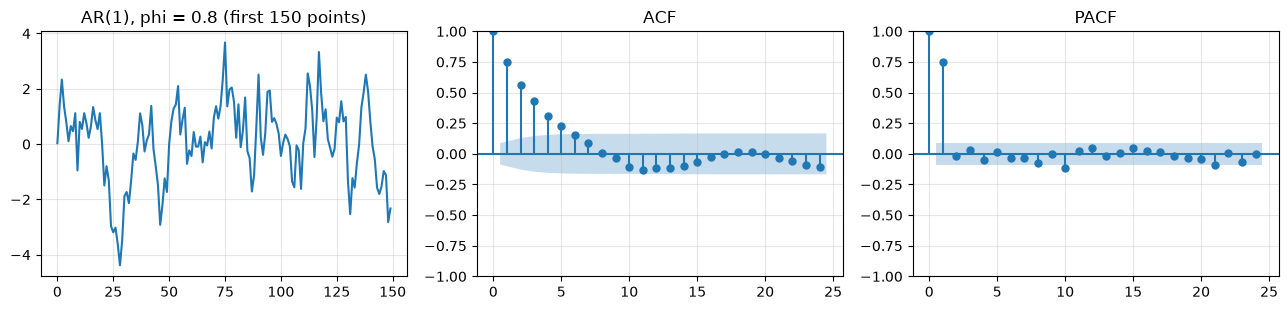

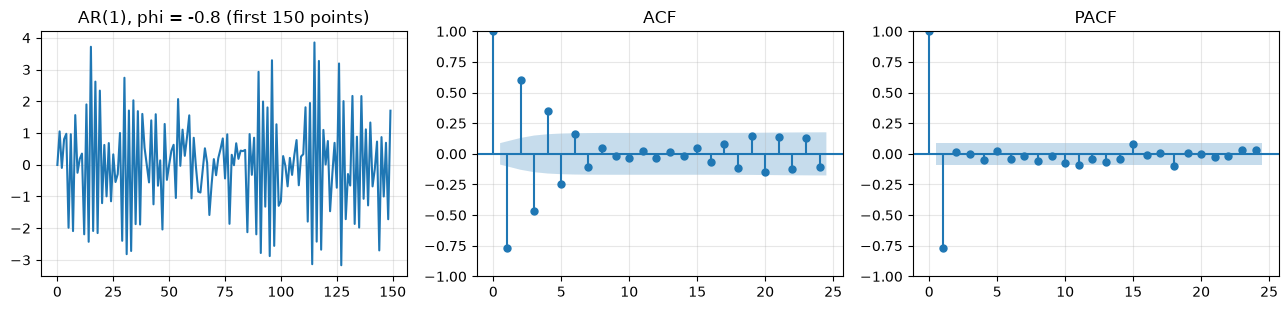

In [3]:
_, ar_pos = simulate(ar=(0.8,), seed=11)
show(ar_pos, "AR(1), phi = 0.8")
_, ar_neg = simulate(ar=(-0.8,), seed=12)
show(ar_neg, "AR(1), phi = -0.8")

**Pattern:** the ACF of an AR process **decays** slowly (geometrically for AR(1)). The PACF **cuts off** after lag $p$. Here the PACF has one spike at lag 1.

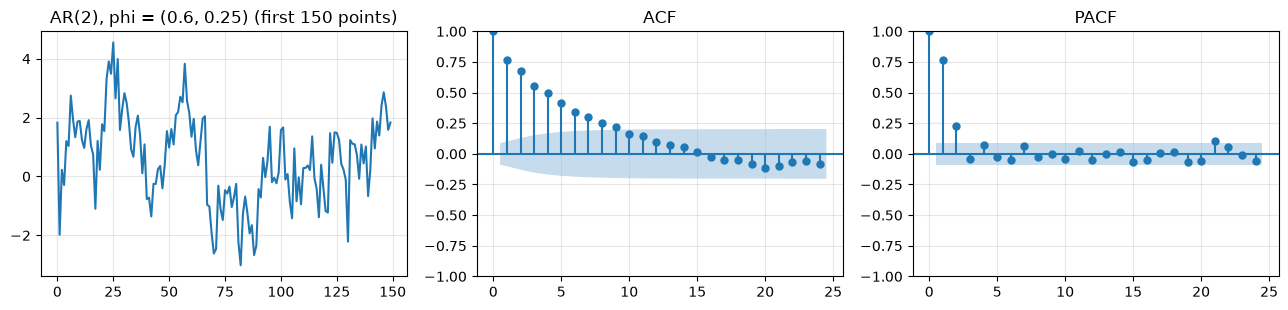

In [4]:
_, ar2 = simulate(ar=(0.6, 0.25), seed=13)
show(ar2, "AR(2), phi = (0.6, 0.25)")

## 2. Moving average processes

An MA($q$) process is a weighted sum of recent shocks:

$$
y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}.
$$

An MA process is always stationary. For a unique representation, it must also be **invertible**, which means the roots of the MA polynomial lie outside the unit circle. For MA(1) this means $|\theta_1| < 1$.

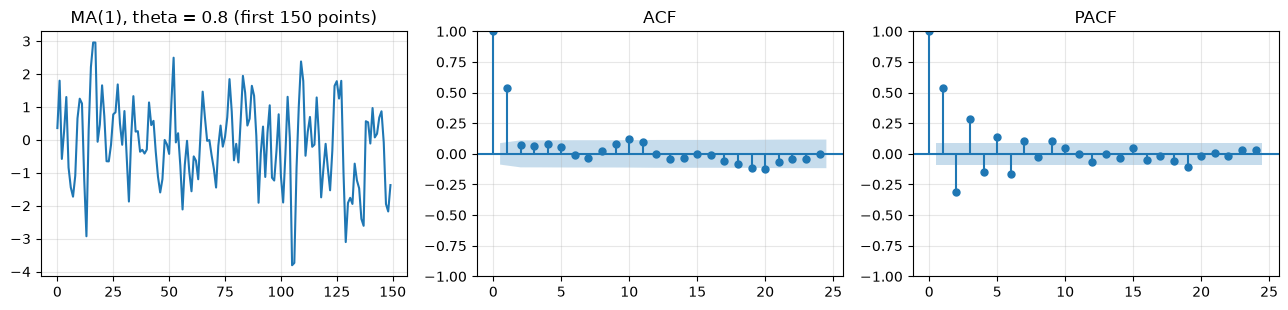

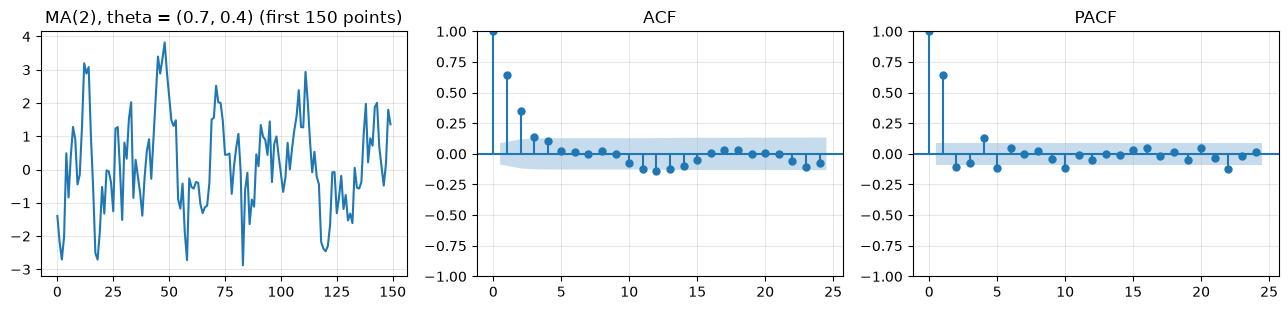

In [5]:
_, ma1 = simulate(ma=(0.8,), seed=21)
show(ma1, "MA(1), theta = 0.8")
_, ma2 = simulate(ma=(0.7, 0.4), seed=22)
show(ma2, "MA(2), theta = (0.7, 0.4)")

**Pattern:** the ACF of an MA process **cuts off** after lag $q$. The PACF **decays**. This is the mirror image of the AR pattern.

## 3. How to read the ACF and PACF

| Process | ACF | PACF |
| --- | --- | --- |
| AR($p$) | Decays (geometric or damped wave) | Cuts off after lag $p$ |
| MA($q$) | Cuts off after lag $q$ | Decays |
| ARMA($p$, $q$) | Decays after lag $q$ | Decays after lag $p$ |
| White noise | No spikes | No spikes |

The blue band is an approximate 95% confidence band, about $\pm 1.96/\sqrt{n}$. Expect about 1 in 20 spikes to cross it by chance. Do not read meaning into one marginal spike at a high lag.

## 4. Theoretical autocovariance

For a stationary AR(1) process, the variance and the autocovariance at lag $h$ have closed forms:

$$
\gamma(0) = \frac{\sigma^2}{1 - \phi^2}, \qquad \gamma(h) = \phi^{h}\,\gamma(0).
$$

Compare the formula with a long simulated sample.

In [6]:
phi, sigma2 = 0.8, 1.0
proc, long_sim = simulate(ar=(phi,), n=100_000, seed=5)

gamma0 = sigma2 / (1 - phi**2)
rows = []
for h in range(5):
    theory = gamma0 * phi**h
    sample = long_sim.autocorr(h) * long_sim.var(ddof=0)   # sample autocovariance
    rows.append({"lag": h, "theoretical gamma(h)": theory, "sample gamma(h)": sample})
pd.DataFrame(rows).round(3)

,lag,theoretical gamma(h),sample gamma(h)
0,0,2.778,2.744
1,1,2.222,2.189
2,2,1.778,1.746
3,3,1.422,1.397
4,4,1.138,1.117


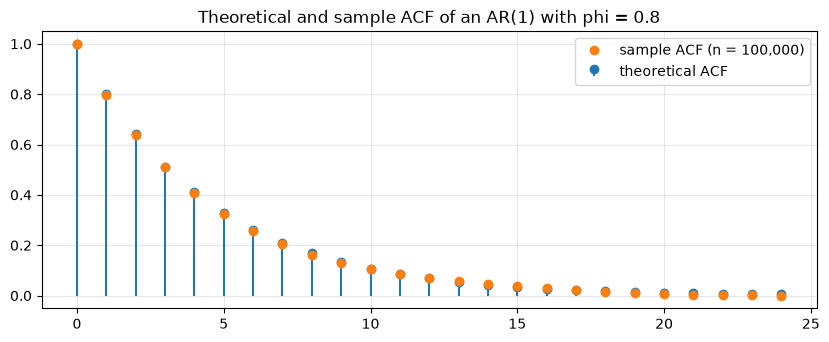

stationary: True | invertible: True
AR roots (must be outside the unit circle): [1.25]


In [7]:
lags = np.arange(0, 25)
fig, ax = plt.subplots()
ax.stem(lags, proc.acf(lags=25), basefmt=" ", label="theoretical ACF")
ax.plot(lags, [long_sim.autocorr(h) for h in lags], "o", color="tab:orange", label="sample ACF (n = 100,000)")
ax.legend()
ax.set_title("Theoretical and sample ACF of an AR(1) with phi = 0.8")
plt.show()

print("stationary:", proc.isstationary, "| invertible:", proc.isinvertible)
print("AR roots (must be outside the unit circle):", np.abs(proc.arroots).round(2))

## 5. Why short samples fool you

With $n = 100$ the sample ACF is noisy. Run the next cell and compare it with the theory above. This is why research reports should state the sample size and use information criteria, not the plot alone.

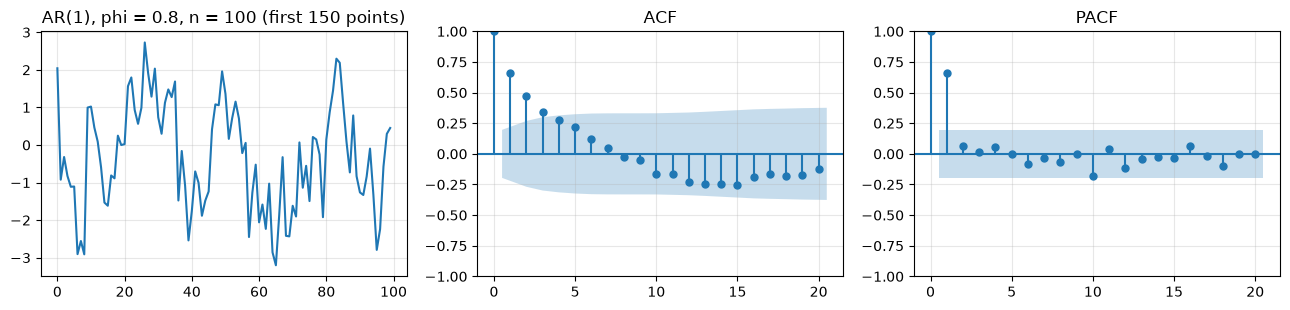

In [8]:
_, short = simulate(ar=(0.8,), n=100, seed=3)
show(short, "AR(1), phi = 0.8, n = 100", lags=20)

## 6. Exercise: identify three mystery series

Each series below has a hidden order. Look at the ACF and PACF, write down your guess, then run the reveal cell.

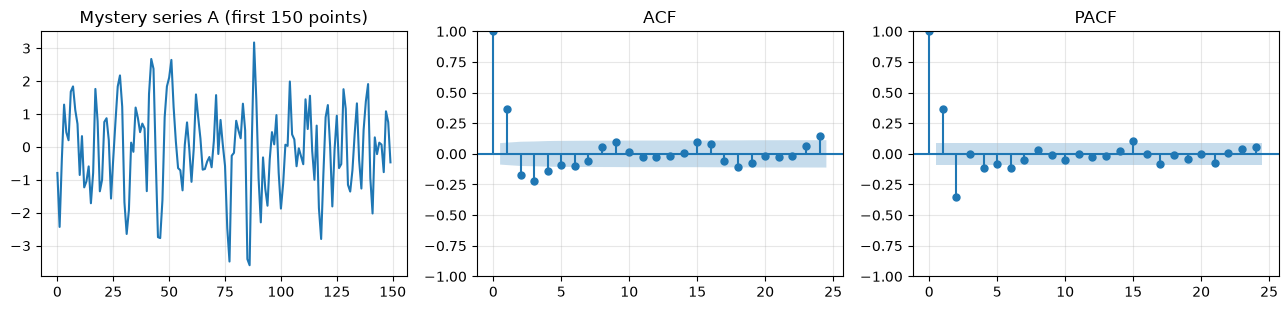

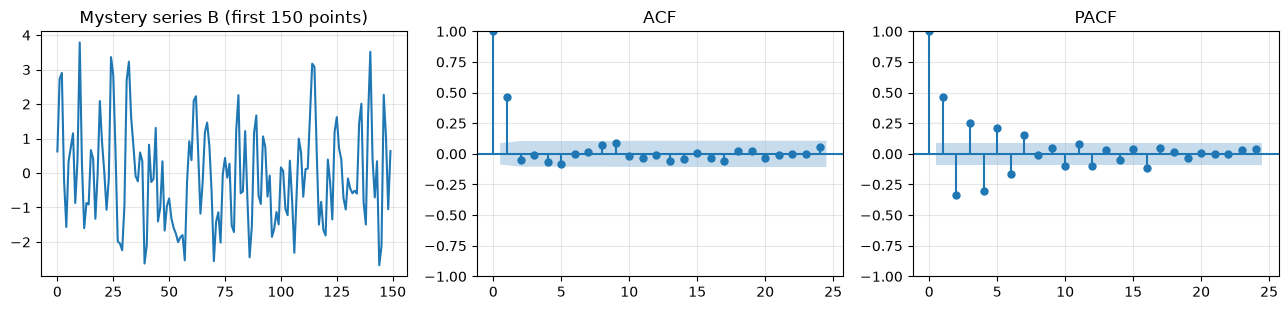

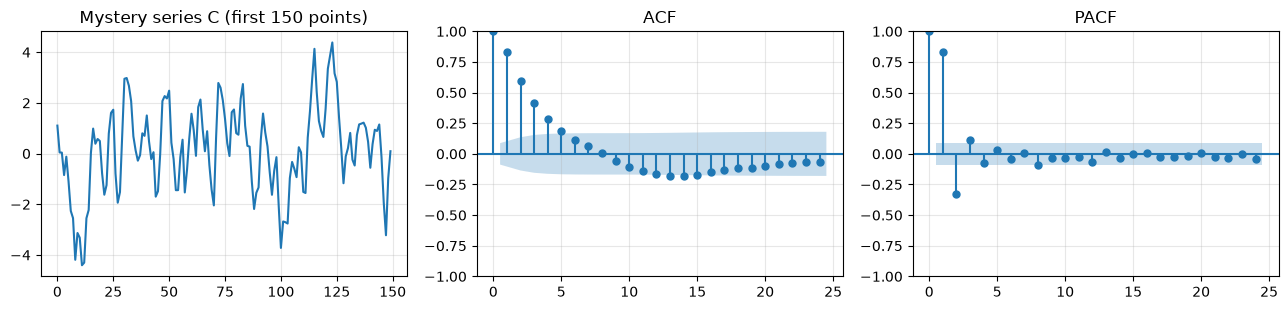

In [9]:
mystery = {
    "A": simulate(ar=(0.5, -0.3), seed=101)[1],
    "B": simulate(ma=(0.9,), seed=102)[1],
    "C": simulate(ar=(0.7,), ma=(0.5,), seed=103)[1],
}
for name, s in mystery.items():
    show(s, f"Mystery series {name}")

Now let the data vote. Fit a small grid of ARMA models to each series and see which order AIC and BIC pick. Both trade fit against the number of parameters, and a lower value is better. BIC penalizes extra parameters more.

In [10]:
from statsmodels.tsa.arima.model import ARIMA

truth = {"A": "AR(2)", "B": "MA(1)", "C": "ARMA(1,1)"}
for name, s in mystery.items():
    scores = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")      # start-value notes from statsmodels, harmless here
        for p in range(3):
            for q in range(3):
                fit = ARIMA(s, order=(p, 0, q), trend="n").fit()
                scores.append((fit.aic, fit.bic, f"ARMA({p},{q})"))
    by_aic = min(scores)[2]
    by_bic = min(scores, key=lambda r: r[1])[2]
    print(f"Series {name}: AIC picks {by_aic:<10} BIC picks {by_bic:<10} hidden truth: {truth[name]}")

Series A: AIC picks ARMA(2,2)  BIC picks ARMA(2,2)  hidden truth: AR(2)
Series B: AIC picks ARMA(2,2)  BIC picks ARMA(0,1)  hidden truth: MA(1)


Series C: AIC picks ARMA(1,1)  BIC picks ARMA(1,1)  hidden truth: ARMA(1,1)


**Take-home**

- AR: ACF decays, PACF cuts off at $p$.
- MA: ACF cuts off at $q$, PACF decays.
- Mixed models: both decay. Use AIC and BIC.
- Simulate first when you meet a new pattern. You control the truth, so you can test your own reading.

**Next:** notebook 03 builds a full ARIMA model on the energy demand data.